In [1]:
import random
import torch

import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/3k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Run CLIP-Dissect

In [5]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

100%|██████████| 188/188 [00:02<00:00, 80.94it/s] 


In [6]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

100%|██████████| 2048/2048 [07:05<00:00,  4.82it/s]


torch.Size([2048, 3000])


## Visualize Results


 Layer:layer4 Neuron:342
1st description: adopt, sim:0.873
2nd description: dog, sim:0.777
3rd description: pet, sim:0.720
5 most highly activating images in D_probe:


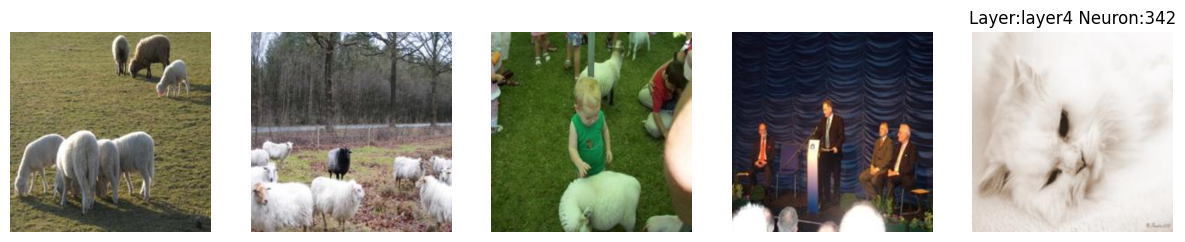


 Layer:layer4 Neuron:1903
1st description: cooking, sim:1.318
2nd description: dining, sim:1.313
3rd description: chef, sim:1.264
5 most highly activating images in D_probe:


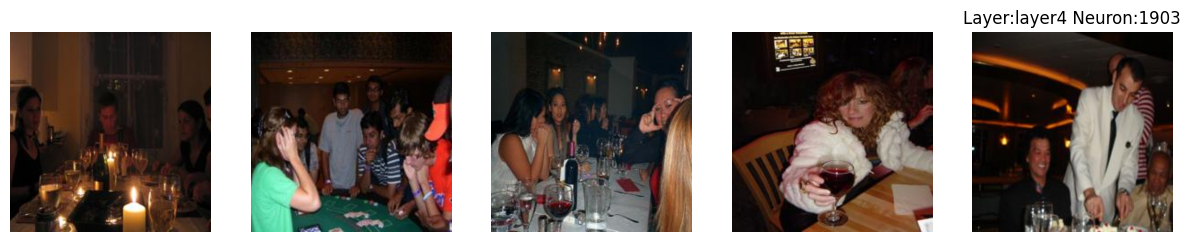


 Layer:layer4 Neuron:437
1st description: stair, sim:1.748
2nd description: wheel, sim:0.999
3rd description: tower, sim:0.890
5 most highly activating images in D_probe:


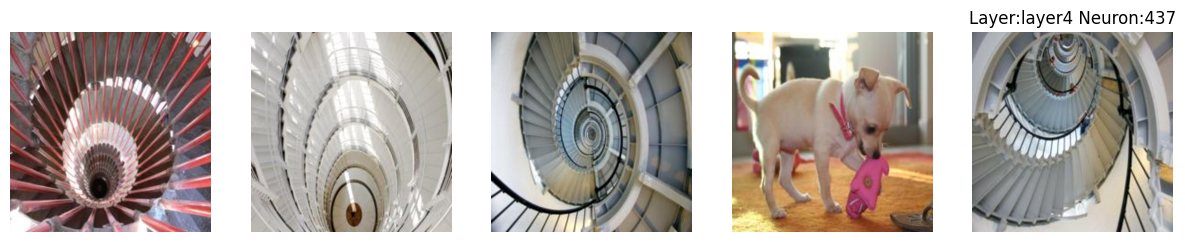


 Layer:layer4 Neuron:1679
1st description: lawn, sim:0.389
2nd description: button, sim:0.383
3rd description: grass, sim:0.339
5 most highly activating images in D_probe:


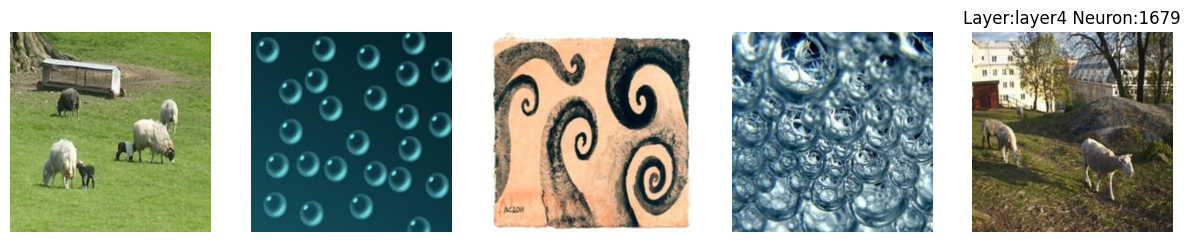


 Layer:layer4 Neuron:1289
1st description: musician, sim:1.286
2nd description: band, sim:0.981
3rd description: instrument, sim:0.963
5 most highly activating images in D_probe:


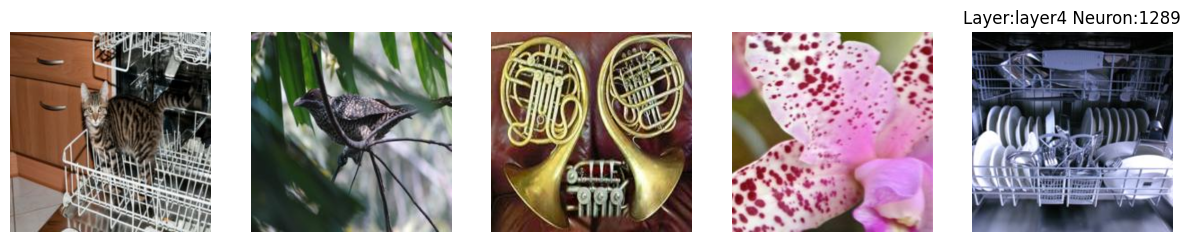


 Layer:layer4 Neuron:614
1st description: floor, sim:1.019
2nd description: household, sim:0.863
3rd description: kitchen, sim:0.858
5 most highly activating images in D_probe:


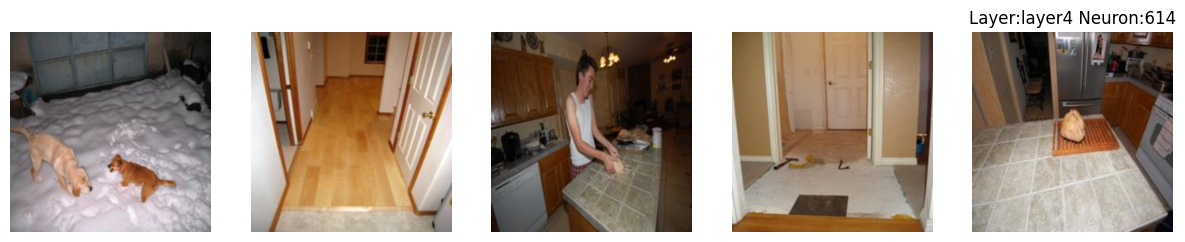


 Layer:layer4 Neuron:1769
1st description: skin, sim:1.556
2nd description: pale, sim:0.997
3rd description: face, sim:0.985
5 most highly activating images in D_probe:


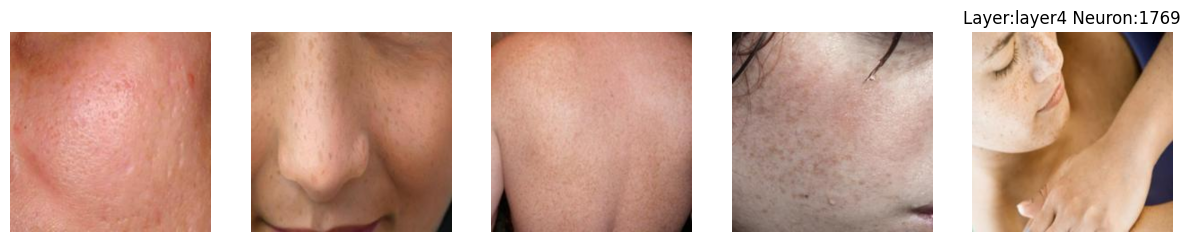


 Layer:layer4 Neuron:1960
1st description: fabric, sim:0.978
2nd description: ceiling, sim:0.955
3rd description: wrap, sim:0.707
5 most highly activating images in D_probe:


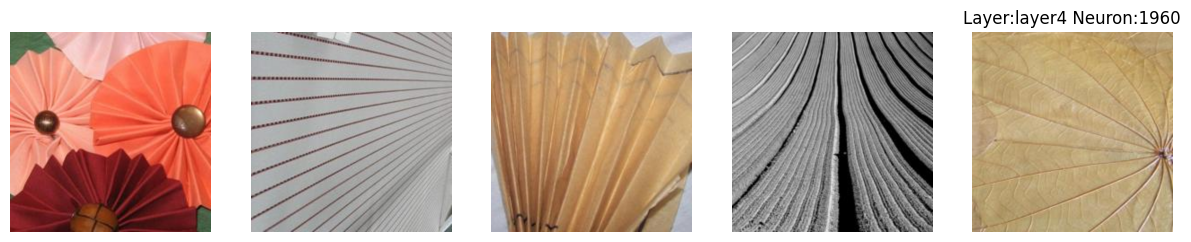


 Layer:layer4 Neuron:1140
1st description: store, sim:1.363
2nd description: shop, sim:1.225
3rd description: organization, sim:0.987
5 most highly activating images in D_probe:


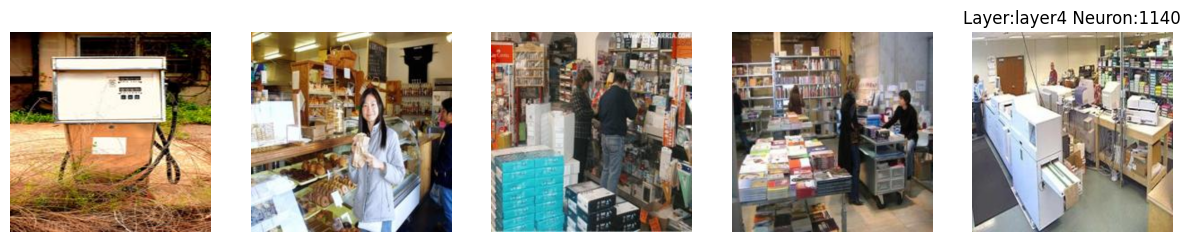


 Layer:layer4 Neuron:199
1st description: shop, sim:1.246
2nd description: store, sim:1.076
3rd description: shopping, sim:1.072
5 most highly activating images in D_probe:


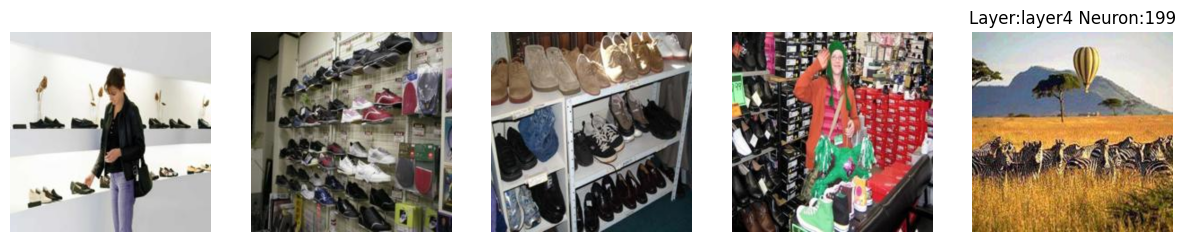

In [7]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

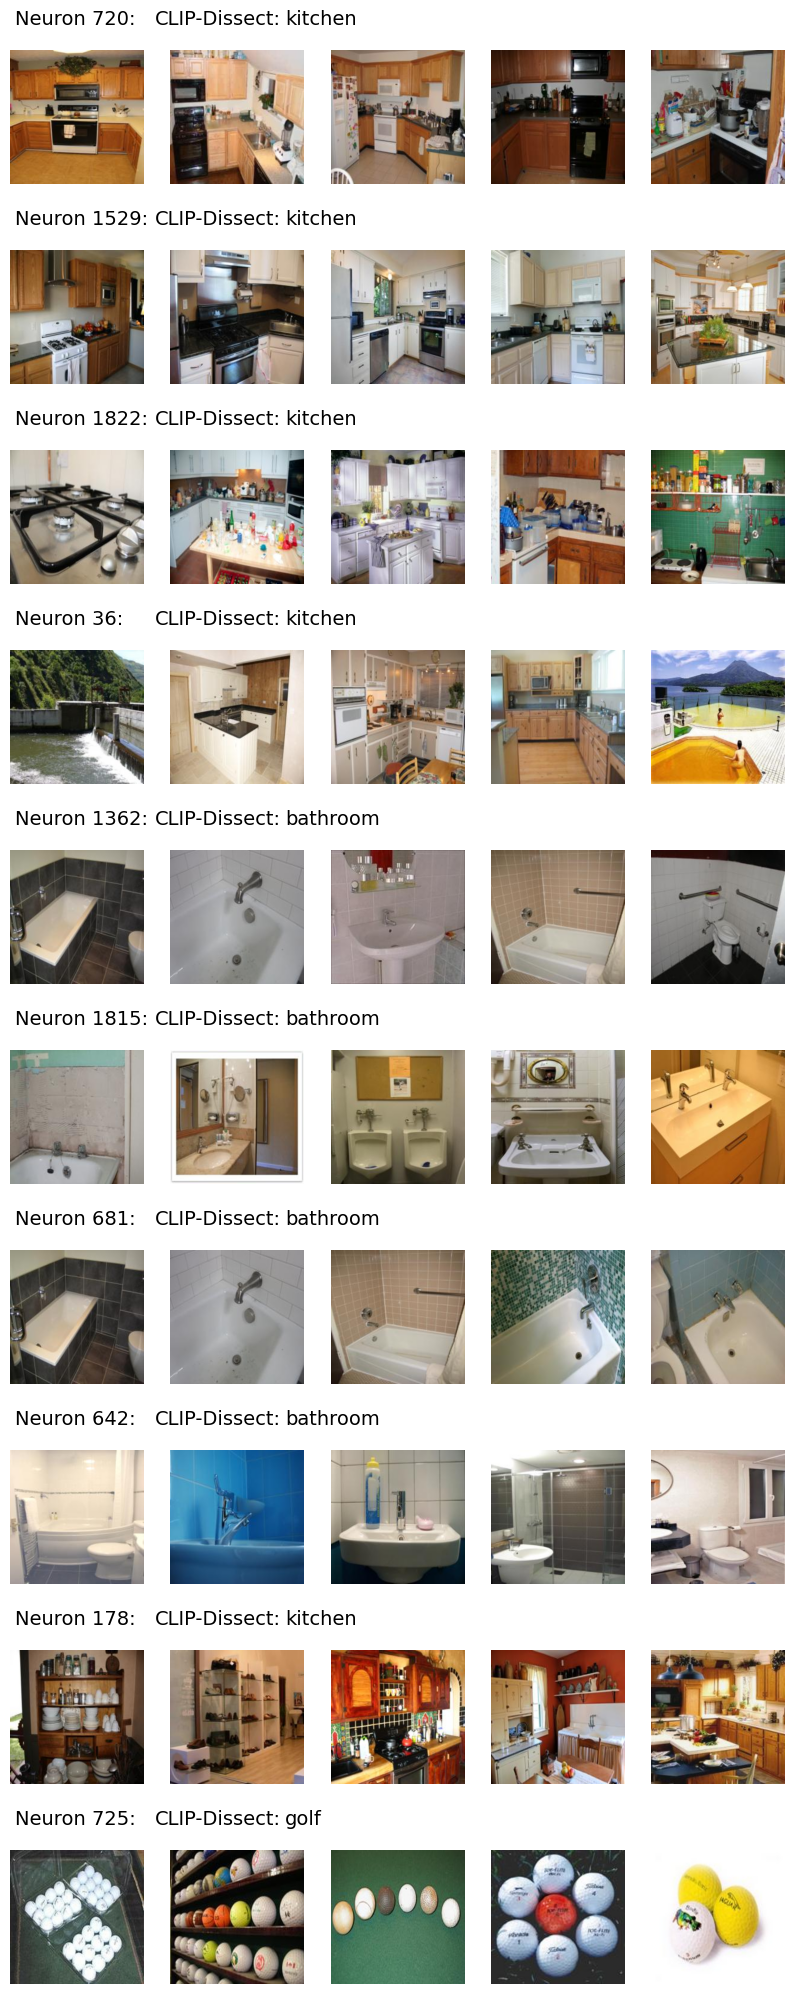

In [8]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()